In [1]:
"""
SAM-Med3D Orthogonal Visualization

Shows same slice number across all 3 anatomical views (Axial, Coronal, Sagittal)
"""

'\nSAM-Med3D Orthogonal Visualization\n\nShows same slice number across all 3 anatomical views (Axial, Coronal, Sagittal)\n'

In [2]:
# Bootstrap required packages (idempotent)
import sys, subprocess, importlib.util

def _ensure_pkg(pip_name, import_name=None):
    name = import_name or pip_name
    if importlib.util.find_spec(name) is None:
        print(f"Installing {pip_name} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pip_name])
    else:
        print(f"OK: {name}")

_ensure_pkg("numpy")
_ensure_pkg("matplotlib")
_ensure_pkg("SimpleITK", "SimpleITK")
_ensure_pkg("torchio")
_ensure_pkg("pyyaml", "yaml")
# Torch is large; just warn if missing
try:
    import torch  # noqa: F401
    print("OK: torch")
except Exception:
    print("WARN: torch not found. Install a suitable CPU/GPU build manually if needed.")

OK: numpy
OK: matplotlib
OK: SimpleITK
OK: torchio
OK: yaml
OK: torch


In [3]:
import sys
from pathlib import Path
import numpy as np
import torch
import SimpleITK as sitk
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
import random
import yaml
import torch.nn.functional as F

In [ ]:
import json
import inspect
from pathlib import Path

# Self-patch: ensure plot_orthogonal_views enforces Z=Y=X with crosshairs
nb_path = Path('SAM_Visualization_ORTHOGONAL_FINAL.ipynb')


def plot_orthogonal_views(
    image_vol,
    seg_vol,
    gt_mask_vol=None,
    title="",
    n_slices=3,
    modality="CT",
    points=None,
    show_crosshair=False,
    crosshair_color='y',
):
    """
    Orthogonal views with SAME index along all axes per point.
    For each n we plot the three planes that intersect at (s_n, s_n, s_n):
      - AXIAL at X=s_n (transverse body cross-section)
      - CORONAL at Y=s_n (front-to-back view)
      - SAGITTAL at Z=s_n (side view)

    Args:
        image_vol: numpy array with image intensities (D, H, W)
        seg_vol: numpy array segmentation (D, H, W)
        gt_mask_vol: optional ground-truth mask (D, H, W)
        title: figure title
        n_slices: number of orthogonal points to render
        modality: string label (CT/MR)
        points: iterable of indices overriding automatic selection
        show_crosshair: if True, draw crosshair lines at the slice location
        crosshair_color: matplotlib color used for crosshair lines
    """
    D, H, W = image_vol.shape
    print("\n" + "=" * 70)
    print(f"📊 Orthogonal Views: {title}")
    print(f"Volume shape: (D={D}, H={H}, W={W})")

    # Display window from foreground only
    fg_mask = image_vol > (image_vol.min() + 0.05 * (image_vol.max() - image_vol.min()))
    if fg_mask.sum() > 100:
        fg = image_vol[fg_mask]
        if "MR" in modality.upper():
            vmin, vmax = np.percentile(fg, [1, 99])
        else:
            mu, sd = fg.mean(), fg.std()
            vmin, vmax = max(mu - 2 * sd, fg.min()), min(mu + 2 * sd, fg.max())
    else:
        vmin, vmax = image_vol.min(), image_vol.max()
    print(f"Display window: [{vmin:.2f}, {vmax:.2f}]")

    # Select indices s so that Z=Y=X=s for each point
    sel = []
    if points is not None and len(points) > 0:
        # Interpret each provided value as s and force (s,s,s)
        ss = []
        for p in points[:n_slices]:
            if isinstance(p, (list, tuple)) and len(p) >= 1:
                s = int(p[0])
            else:
                s = int(p)
            ss.append(s)
        sel = [(int(np.clip(s, 0, min(D, H, W) - 1)),) * 3 for s in ss]
    elif gt_mask_vol is not None and gt_mask_vol.sum() > 0:
        coords = np.argwhere(gt_mask_vol > 0)
        z_min, y_min, x_min = coords.min(axis=0)
        z_max, y_max, x_max = coords.max(axis=0)
        rng_min = int(max(z_min, y_min, x_min))
        rng_max = int(min(z_max, y_max, x_max))
        if rng_max >= rng_min:
            ss = np.linspace(rng_min, rng_max, n_slices).astype(int)
        else:
            # No overlap across axes; use averaged center
            cz = (z_min + z_max) / 2
            cy = (y_min + y_max) / 2
            cx = (x_min + x_max) / 2
            s0 = int(round((cz + cy + cx) / 3))
            half = max(1, min(D, H, W) // 10)
            ss = np.linspace(max(0, s0 - half), min(min(D, H, W) - 1, s0 + half), n_slices).astype(int)
        sel = [(int(np.clip(s, 0, min(D, H, W) - 1)),) * 3 for s in ss]
    else:
        mid = min(D, H, W) // 2
        half = max(1, min(D, H, W) // 10)
        ss = np.linspace(max(0, mid - half), min(min(D, H, W) - 1, mid + half), n_slices).astype(int)
        sel = [(int(s), int(s), int(s)) for s in ss]

    print('Selected 3D points (Z=Y=X):', sel)

    n_cols = 2 if gt_mask_vol is not None else 1
    fig = plt.figure(figsize=(5 * 2, 4 * len(sel)))

    def _maybe_crosshair(ax_obj, horiz, vert):
        if show_crosshair:
            ax_obj.axhline(horiz, color=crosshair_color, alpha=0.6, lw=0.6)
            ax_obj.axvline(vert, color=crosshair_color, alpha=0.6, lw=0.6)

    for i, (z, y, x) in enumerate(sel):
        # AXIAL (transverse body cross-section) - circular view in abdomen
        # Extract from W dimension (third axis)
        img_a = np.rot90(image_vol[:, :, x].T, k=0)
        seg_a = np.rot90(seg_vol[:, :, x].T, k=0)
        gt_a = np.rot90(gt_mask_vol[:, :, x].T, k=0) if gt_mask_vol is not None else None
        base = (i * 3) * n_cols
        ax = fig.add_subplot(len(sel) * 3, n_cols, base + 1)
        ax.imshow(img_a, cmap='gray', vmin=vmin, vmax=vmax)
        ax.imshow(np.ma.masked_where(seg_a == 0, seg_a), cmap='Reds', alpha=0.5, vmin=0, vmax=1)
        _maybe_crosshair(ax, z, y)
        ax.set_title(f'AXIAL SAM (X={x})')
        ax.axis('off')
        if gt_mask_vol is not None:
            ax = fig.add_subplot(len(sel) * 3, n_cols, base + 2)
            ax.imshow(img_a, cmap='gray', vmin=vmin, vmax=vmax)
            ax.imshow(np.ma.masked_where(gt_a == 0, gt_a), cmap='Greens', alpha=0.5, vmin=0, vmax=1)
            _maybe_crosshair(ax, z, y)
            ax.set_title(f'AXIAL GT (X={x})')
            ax.axis('off')

        # CORONAL (front-to-back view)
        img_c = np.rot90(image_vol[:, y, :].T, k=0)
        seg_c = np.rot90(seg_vol[:, y, :].T, k=0)
        gt_c = np.rot90(gt_mask_vol[:, y, :].T, k=0) if gt_mask_vol is not None else None
        base = (i * 3 + 1) * n_cols
        ax = fig.add_subplot(len(sel) * 3, n_cols, base + 1)
        ax.imshow(img_c, cmap='gray', vmin=vmin, vmax=vmax)
        ax.imshow(np.ma.masked_where(seg_c == 0, seg_c), cmap='Reds', alpha=0.5, vmin=0, vmax=1)
        _maybe_crosshair(ax, z, x)
        ax.set_title(f'CORONAL SAM (Y={y})')
        ax.axis('off')
        if gt_mask_vol is not None:
            ax = fig.add_subplot(len(sel) * 3, n_cols, base + 2)
            ax.imshow(img_c, cmap='gray', vmin=vmin, vmax=vmax)
            ax.imshow(np.ma.masked_where(gt_c == 0, gt_c), cmap='Greens', alpha=0.5, vmin=0, vmax=1)
            _maybe_crosshair(ax, z, x)
            ax.set_title(f'CORONAL GT (Y={y})')
            ax.axis('off')

        # SAGITTAL (side view) - elongated view
        # Extract from D dimension (first axis)
        img_s = np.rot90(image_vol[z, :, :], k=1)
        seg_s = np.rot90(seg_vol[z, :, :], k=1)
        gt_s = np.rot90(gt_mask_vol[z, :, :], k=1) if gt_mask_vol is not None else None
        base = (i * 3 + 2) * n_cols
        ax = fig.add_subplot(len(sel) * 3, n_cols, base + 1)
        ax.imshow(img_s, cmap='gray', vmin=vmin, vmax=vmax)
        ax.imshow(np.ma.masked_where(seg_s == 0, seg_s), cmap='Reds', alpha=0.5, vmin=0, vmax=1)
        _maybe_crosshair(ax, y, x)
        ax.set_title(f'SAGITTAL SAM (Z={z})')
        ax.axis('off')
        if gt_mask_vol is not None:
            ax = fig.add_subplot(len(sel) * 3, n_cols, base + 2)
            ax.imshow(img_s, cmap='gray', vmin=vmin, vmax=vmax)
            ax.imshow(np.ma.masked_where(gt_s == 0, gt_s), cmap='Greens', alpha=0.5, vmin=0, vmax=1)
            _maybe_crosshair(ax, y, x)
            ax.set_title(f'SAGITTAL GT (Z={z})')
            ax.axis('off')

    fig.suptitle(f"{title}\n[Orthogonal Views - Equal Indices (Z=Y=X) | {modality}]", fontsize=14)
    plt.tight_layout()
    return fig


def _cell_has_equal_indices(src_list):
    s = ''.join(src_list)
    return ('Orthogonal Views - Equal Indices (Z=Y=X)' in s) and ('Selected 3D points (Z=Y=X)' in s)


if nb_path.exists():
    nb = json.loads(nb_path.read_text(encoding='utf-8'))
    new_func_src = inspect.getsource(plot_orthogonal_views)
    new_func_lines = [line + '\n' for line in new_func_src.splitlines()]

    updated = False
    cell_index = None
    for i, c in enumerate(nb['cells']):
        if c.get('cell_type') == 'code' and any('def plot_orthogonal_views' in s for s in c.get('source', [])):
            cell_index = i
            if not _cell_has_equal_indices(c.get('source', [])):
                nb['cells'][i]['source'] = new_func_lines
                updated = True
            break

    if cell_index is None:
        nb['cells'].append({
            'cell_type': 'code',
            'metadata': {},
            'source': new_func_lines,
            'outputs': [],
            'execution_count': None,
        })
        updated = True

    if updated:
        nb_path.write_text(json.dumps(nb, indent=1, ensure_ascii=False), encoding='utf-8')
        print('Patched plot_orthogonal_views in notebook. Restart kernel and Run All.')
    else:
        print('plot_orthogonal_views already up-to-date.')
else:
    print("Skipping self-patch: SAM_Visualization_ORTHOGONAL_FINAL.ipynb not found.")

Skipping self-patch: SAM_Visualization_ORTHOGONAL_FINAL.ipynb not found.


In [5]:
# Add project root to path (Notebook-compatible)
# Notebook is in notebooks/visualization/, need to go up 2 levels
project_root = Path.cwd().parent.parent  # Go up from notebooks/visualization/ to project root
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
    
# Verify med3pipe is accessible
try:
    import med3pipe
    print(f"✅ med3pipe imported successfully from: {med3pipe.__file__}")
except ImportError as e:
    print(f"❌ Cannot import med3pipe. Project root: {project_root}")
    print(f"   sys.path includes: {project_root in [Path(p) for p in sys.path]}")
    print(f"   Error: {e}")

c:\Users\cahel\.conda\envs\sammed3d\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ med3pipe imported successfully from: c:\Users\cahel\Desktop\Med3Tab-PFN\med3pipe\__init__.py


In [6]:
from med3pipe.sam.core import build_sam3d_model, find_default_sam3d_root
from med3pipe.sam.transforms import ResizeLargestTo
import torchio as tio

In [7]:
print(f"✅ Project root: {project_root}")

✅ Project root: c:\Users\cahel\Desktop\Med3Tab-PFN


============================================================================
Configuration
============================================================================

In [8]:
config_path = project_root / "configs" / "datasets_analysis.yaml"
with open(config_path) as f:
    config = yaml.safe_load(f)

In [9]:
sam3d_root = find_default_sam3d_root()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
img_size = 128

In [10]:
# Ensure SAM-Med3D checkpoint is present at MANUAL_CHECKPOINT
from pathlib import Path
import os

MANUAL_CHECKPOINT =r"C:\Users\cahel\Desktop\Med3Tab-PFN\SAM-Med3D-main\SAM-Med3D-main\ckpt\sam_med3d_turbo.pth"
ckpt_path = Path(MANUAL_CHECKPOINT)
ckpt_dir = ckpt_path.parent
ckpt_dir.mkdir(parents=True, exist_ok=True)

if not ckpt_path.exists():
    url = "https://huggingface.co/blueyo0/SAM-Med3D/resolve/main/sam_med3d_turbo.pth"
    print(f"Checkpoint missing. Downloading to: {ckpt_path}")
    try:
        import urllib.request, shutil
        req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
        with urllib.request.urlopen(req) as r, open(ckpt_path, 'wb') as f:
            shutil.copyfileobj(r, f)
        size_mb = ckpt_path.stat().st_size / (1024*1024)
        print(f"✅ Download complete: {size_mb:.1f} MB")
        if size_mb < 300:
            print("⚠️  File size is unexpectedly small. If loading fails, delete the file and rerun this cell.")
    except Exception as e:
        print(f"❌ Failed to download checkpoint: {e}")
        print("You can manually download from:")
        print(url)
else:
    size_mb = ckpt_path.stat().st_size / (1024*1024)
    print(f"✅ Checkpoint present: {ckpt_path} ({size_mb:.1f} MB)")

✅ Checkpoint present: C:\Users\cahel\Desktop\Med3Tab-PFN\SAM-Med3D-main\SAM-Med3D-main\ckpt\sam_med3d_turbo.pth (383.5 MB)


In [11]:
# Optional: Manually specify checkpoint path (set to None for auto-detection)
MANUAL_CHECKPOINT = Path("../../SAM-Med3D-main/SAM-Med3D-main/ckpt/sam_med3d_turbo.pth")

In [12]:
# SAM Segmentation Settings
USE_SINGLE_POINT_PROMPT = True  # True = less over-segmentation, False = more complete segmentation
SEGMENTATION_THRESHOLD = 0.5    # Increase to 0.7 or 0.8 if SAM over-segments (shows red everywhere)

In [13]:
# Visualization Settings
AUTO_CROP_PADDING = True        # True = remove padding (cleaner), False = show full 128³ volume
SKIP_EDGE_SLICES = True         # True = avoid edge artifacts, False = use all slices
PLOT_SAMPLES_PER_DATASET = 2    # Number of cases to visualize per dataset

In [14]:
print(f"Using device: {device}")
print(f"SAM-Med3D root: {sam3d_root}")
print(f"Available datasets: {list(config['datasets'].keys())}")

Using device: cpu
SAM-Med3D root: C:\Users\cahel\Desktop\Med3Tab-PFN\SAM-Med3D-main\SAM-Med3D-main
Available datasets: ['crlm', 'desmoid', 'gist', 'lipo', 'liver', 'melanoma']


============================================================================
Build SAM-Med3D Model
============================================================================

In [15]:
print("\nLoading SAM-Med3D model...")


Loading SAM-Med3D model...


In [16]:
# Check if manual checkpoint is specified
if MANUAL_CHECKPOINT is not None:
    checkpoint_path = Path(MANUAL_CHECKPOINT)
    if checkpoint_path.exists():
        print(f"✅ Using manually specified checkpoint: {checkpoint_path}")
    else:
        print(f"❌ Manual checkpoint not found: {checkpoint_path}")
        checkpoint_path = None
else:
    # Try multiple possible checkpoint locations
    possible_checkpoints = [
        sam3d_root / "work_dir" / "SAM" / "sam_model_best.pth",
        sam3d_root / "work_dir" / "sam_model_best.pth",
        sam3d_root / "ckpt" / "sam_med3d_turbo.pth",
        sam3d_root / "sam_model_best.pth",
        sam3d_root / "work_dir" / "SAM-Med3D" / "sam_model_best.pth",
    ]
    
    checkpoint_path = None
    for path in possible_checkpoints:
        if path.exists():
            checkpoint_path = path
            print(f"✅ Found checkpoint: {path}")
            break
    
    if checkpoint_path is None:
        print("⚠️  No checkpoint found. Loading model without pretrained weights.")
        print(f"   Searched locations:")
        for p in possible_checkpoints:
            print(f"   - {p}")
        print(f"\n   💡 Tip: Set MANUAL_CHECKPOINT variable to specify checkpoint manually")

✅ Using manually specified checkpoint: ..\..\SAM-Med3D-main\SAM-Med3D-main\ckpt\sam_med3d_turbo.pth


In [17]:
if checkpoint_path is not None:
    print(f"📦 Loading checkpoint from: {checkpoint_path}")

📦 Loading checkpoint from: ..\..\SAM-Med3D-main\SAM-Med3D-main\ckpt\sam_med3d_turbo.pth


In [18]:
model = build_sam3d_model(
    sam3d_root=sam3d_root,
    model_type="vit_b_ori",
    checkpoint=checkpoint_path,
    device=device,
    eval_mode=True
)
print("✅ SAM-Med3D model loaded successfully!")

Loaded checkpoint (model_state_dict)
✅ SAM-Med3D model loaded successfully!


============================================================================
Preprocessing Functions (FIXED for SAM)
============================================================================

In [19]:
print("\n" + "="*70)
print("📋 Preprocessing: Resize-then-Pad + Z-Normalization")
print("="*70)
print("✅ ToCanonical - standard orientation")
print("✅ ResizeLargestTo(128) - preserves all data")
print("✅ CropOrPad(128³) - minimal padding")
print("✅ ZNormalization - CRITICAL for SAM (fixes segmentation)")
print()


📋 Preprocessing: Resize-then-Pad + Z-Normalization
✅ ToCanonical - standard orientation
✅ ResizeLargestTo(128) - preserves all data
✅ CropOrPad(128³) - minimal padding
✅ ZNormalization - CRITICAL for SAM (fixes segmentation)



In [20]:
def _znorm_masking_method(x):
    """Masking method for ZNormalization."""
    return x > 0

In [21]:
def load_volume_for_sam(img_path, img_size=128):
    """
    Load volume with proper preprocessing FOR SAM.
    
    IMPORTANT: SAM needs normalized input! Without it, segmentation fails.
    """
    sitk_img = sitk.ReadImage(str(img_path))
    sitk_arr, _ = tio.data.io.sitk_to_nib(sitk_img)
    subject = tio.Subject(image=tio.ScalarImage(tensor=sitk_arr))
    
    # Apply CT clamping if this is a CT image
    if "/ct_" in str(img_path).lower() or "_ct" in str(img_path).lower():
        subject = tio.Clamp(-1000, 1000)(subject)
    
    # Resize-then-pad + NORMALIZATION (critical for SAM!)
    transform = tio.Compose([
        tio.ToCanonical(),
        ResizeLargestTo(target_size=img_size),
        tio.CropOrPad(target_shape=(img_size, img_size, img_size)),
        tio.ZNormalization(masking_method=_znorm_masking_method),  # CRITICAL!
    ])
    subject = transform(subject)
    
    image = subject.image.data.clone().detach()
    image = image.unsqueeze(0)  # (1, 1, D, H, W)
    image = image.float()
    return image

In [22]:
def load_mask_for_sam(mask_path, img_size=128):
    """Load mask with resize-then-pad preprocessing."""
    sitk_mask = sitk.ReadImage(str(mask_path))
    mask_arr, _ = tio.data.io.sitk_to_nib(sitk_mask)
    subject = tio.Subject(label=tio.LabelMap(tensor=mask_arr))
    
    transform = tio.Compose([
        tio.ToCanonical(),
        ResizeLargestTo(target_size=img_size),
        tio.CropOrPad(target_shape=(img_size, img_size, img_size)),
    ])
    subject = transform(subject)
    
    mask = subject.label.data.squeeze().numpy()
    mask = (mask > 0).astype(float)
    return mask

In [23]:
def load_volume_for_display(img_path, img_size=128):
    """
    Load volume for DISPLAY (without normalization).
    
    Use this for visualization so images look natural.
    """
    sitk_img = sitk.ReadImage(str(img_path))
    sitk_arr, _ = tio.data.io.sitk_to_nib(sitk_img)
    subject = tio.Subject(image=tio.ScalarImage(tensor=sitk_arr))
    
    # Apply CT clamping if needed
    if "/ct_" in str(img_path).lower() or "_ct" in str(img_path).lower():
        subject = tio.Clamp(-1000, 1000)(subject)
    
    # Resize-then-pad (NO normalization for display)
    transform = tio.Compose([
        tio.ToCanonical(),
        ResizeLargestTo(target_size=img_size),
        tio.CropOrPad(target_shape=(img_size, img_size, img_size)),
    ])
    subject = transform(subject)
    
    image = subject.image.data.squeeze().numpy()
    return image

============================================================================
Helper Functions
============================================================================

In [24]:
def find_dataset_images(dataset_config, sam3d_root, project_root):
    """Find all images and labels for a dataset."""
    images, labels = [], []
    category = dataset_config['category']
    ct_name = dataset_config['ct_name']
    
    possible_paths = [
        sam3d_root / 'data' / 'train' / category / ct_name / 'imagesTr',
        sam3d_root / 'data' / 'validation' / category / ct_name / 'imagesVal',
    ]
    
    for path in possible_paths:
        if path.exists():
            imgs = list(path.glob('*.nii.gz'))
            images.extend(imgs)
            label_path = path.parent / path.name.replace('images', 'labels')
            if label_path.exists():
                for img in imgs:
                    label_file = label_path / img.name
                    if label_file.exists():
                        labels.append(label_file)
    return images, labels

============================================================================
SAM-Med3D Segmentation Functions
============================================================================

In [25]:
def generate_sam_with_bbox_prompt(model, image_tensor, gt_mask_tensor, device, use_single_point=True):
    """
    Generate segmentation using prompts from ground truth.
    
    Args:
        use_single_point: If True, uses only center point (more conservative).
                         If False, uses 3 points (can over-segment).
    """
    model.eval()
    with torch.no_grad():
        input_tensor = image_tensor.to(device)
        image_embeddings = model.image_encoder(input_tensor)
        
        D, H, W = input_tensor.shape[2:]
        
        coords = np.argwhere(gt_mask_tensor > 0)
        if len(coords) == 0:
            # Fallback to center point if no GT
            center_point = torch.tensor([[[W//2, H//2, D//2]]], device=device, dtype=torch.float)
            point_labels = torch.tensor([[1]], device=device, dtype=torch.int64)
            print("    ⚠️  No ground truth mask found, using image center")
        else:
            z_min, y_min, x_min = coords.min(axis=0)
            z_max, y_max, x_max = coords.max(axis=0)
            
            # Calculate center of the mask
            center_x = (x_min + x_max) // 2
            center_y = (y_min + y_max) // 2
            center_z = (z_min + z_max) // 2
            
            if use_single_point:
                # SINGLE POINT: More conservative, less over-segmentation
                points_list = [[center_x, center_y, center_z]]
                center_point = torch.tensor([points_list], device=device, dtype=torch.float)
                point_labels = torch.tensor([[1]], device=device, dtype=torch.int64)
                print(f"    Using SINGLE point prompt at: ({center_x}, {center_y}, {center_z})")
            else:
                # MULTIPLE POINTS: Can cause over-segmentation
                points_list = [[center_x, center_y, center_z],
                              [x_min + (x_max-x_min)//4, center_y, center_z],
                              [x_max - (x_max-x_min)//4, center_y, center_z]]
                center_point = torch.tensor([points_list], device=device, dtype=torch.float)
                point_labels = torch.tensor([[1, 1, 1]], device=device, dtype=torch.int64)
                print(f"    Using 3-point prompt")
        
        # Generate segmentation
        low_res_shape = (1, 1, D//4, H//4, W//4)
        prev_low_res_mask = torch.zeros(low_res_shape, device=device, dtype=torch.float)
        
        sparse_embeddings, dense_embeddings = model.prompt_encoder(
            points=[center_point, point_labels], boxes=None, masks=prev_low_res_mask)
        low_res_masks, _ = model.mask_decoder(
            image_embeddings=image_embeddings,
            image_pe=model.prompt_encoder.get_dense_pe(),
            sparse_prompt_embeddings=sparse_embeddings,
            dense_prompt_embeddings=dense_embeddings,
            multimask_output=False)
        
        final_masks_hr = F.interpolate(low_res_masks, size=(D, H, W), mode='trilinear', align_corners=False)
        seg_prob = torch.sigmoid(final_masks_hr)
        
        # Apply threshold (configured at top of script)
        seg_mask = (seg_prob > SEGMENTATION_THRESHOLD).cpu().squeeze().numpy().astype(np.uint8)
        
        # Debug: print stats
        print(f"    Segmentation stats: min={seg_prob.min():.3f}, max={seg_prob.max():.3f}, "
              f"threshold={SEGMENTATION_THRESHOLD}, voxels={seg_mask.sum()}")
    
    return seg_mask

In [26]:
def compute_dice_score(pred_mask, gt_mask):
    """
    Compute Dice coefficient between prediction and ground truth.
    
    Args:
        pred_mask: Predicted segmentation mask (numpy array)
        gt_mask: Ground truth mask (numpy array)
        
    Returns:
        Dice score (float between 0 and 1)
    """
    # Ensure binary masks
    pred_mask = (pred_mask > 0).astype(np.float32)
    gt_mask = (gt_mask > 0).astype(np.float32)
    
    # Compute intersection and union
    intersection = np.sum(pred_mask * gt_mask)
    pred_sum = np.sum(pred_mask)
    gt_sum = np.sum(gt_mask)
    
    # Handle edge case where both masks are empty
    if pred_sum == 0 and gt_sum == 0:
        return 1.0
    
    # Compute Dice score
    dice = (2.0 * intersection) / (pred_sum + gt_sum + 1e-8)
    
    return dice

In [27]:
def generate_sam_unprompted(model, image_tensor, device, threshold=0.5):
    """
    Generate segmentation WITHOUT prompts (automatic mode).
    Uses the image center as a single point prompt.
    
    Args:
        model: SAM model
        image_tensor: Input image tensor (1, 1, D, H, W)
        device: torch device
        threshold: Segmentation threshold (default 0.5)
        
    Returns:
        Segmentation mask (numpy array)
    """
    model.eval()
    with torch.no_grad():
        input_tensor = image_tensor.to(device)
        image_embeddings = model.image_encoder(input_tensor)
        
        D, H, W = input_tensor.shape[2:]
        
        # Use image center as the only prompt (unprompted baseline)
        center_point = torch.tensor([[[W//2, H//2, D//2]]], device=device, dtype=torch.float)
        point_labels = torch.tensor([[1]], device=device, dtype=torch.int64)
        
        print(f"    Using CENTER point (unprompted): ({W//2}, {H//2}, {D//2})")
        
        # Generate segmentation
        low_res_shape = (1, 1, D//4, H//4, W//4)
        prev_low_res_mask = torch.zeros(low_res_shape, device=device, dtype=torch.float)
        
        sparse_embeddings, dense_embeddings = model.prompt_encoder(
            points=[center_point, point_labels], boxes=None, masks=prev_low_res_mask)
        low_res_masks, _ = model.mask_decoder(
            image_embeddings=image_embeddings,
            image_pe=model.prompt_encoder.get_dense_pe(),
            sparse_prompt_embeddings=sparse_embeddings,
            dense_prompt_embeddings=dense_embeddings,
            multimask_output=False)
        
        final_masks_hr = F.interpolate(low_res_masks, size=(D, H, W), mode='trilinear', align_corners=False)
        seg_prob = torch.sigmoid(final_masks_hr)
        
        seg_mask = (seg_prob > threshold).cpu().squeeze().numpy().astype(np.uint8)
        
        print(f"    Unprompted segmentation stats: min={seg_prob.min():.3f}, max={seg_prob.max():.3f}, "
              f"threshold={threshold}, voxels={seg_mask.sum()}")
    
    return seg_mask

============================================================================
Plotting Function (CORONAL VIEW - Auto-detect modality)
============================================================================

In [28]:
def plot_coronal_slices(image_vol, seg_vol, gt_mask_vol=None, title="", n_slices=5, modality="CT"):
    """
    Plot CORONAL slices (front-to-back view).
    
    Auto-adjusts dimension based on modality:
    - CT (GIST): dimension 1
    - MR (LIPO): dimension 2
    
    Intelligently selects slices where data actually exists.
    Auto-crops to remove padding artifacts.
    """
    D, H, W = image_vol.shape
    
    # Auto-crop to actual data region (remove padding) - but keep it conservative
    # Only if enabled in settings
    if AUTO_CROP_PADDING:
        threshold = image_vol.min() + 0.02 * (image_vol.max() - image_vol.min())
        mask_nonzero = np.abs(image_vol) > threshold
    
        if mask_nonzero.sum() > 1000:  # Only crop if we have enough foreground
            coords = np.argwhere(mask_nonzero)
            d_min, h_min, w_min = coords.min(axis=0)
            d_max, h_max, w_max = coords.max(axis=0)
            
            # Add generous margin to avoid over-cropping
            d_margin = max(5, int((d_max - d_min) * 0.05))
            h_margin = max(5, int((h_max - h_min) * 0.05))
            w_margin = max(5, int((w_max - w_min) * 0.05))
            
            d_min = max(0, d_min - d_margin)
            h_min = max(0, h_min - h_margin)
            w_min = max(0, w_min - w_margin)
            d_max = min(D-1, d_max + d_margin)
            h_max = min(H-1, h_max + h_margin)
            w_max = min(W-1, w_max + w_margin)
            
            # Only crop if it actually removes significant padding
            new_size = (d_max - d_min + 1) * (h_max - h_min + 1) * (w_max - w_min + 1)
            orig_size = D * H * W
            
            if new_size < orig_size * 0.85:  # Only if we remove >15% of volume
                # Crop to actual data
                image_vol = image_vol[d_min:d_max+1, h_min:h_max+1, w_min:w_max+1]
                seg_vol = seg_vol[d_min:d_max+1, h_min:h_max+1, w_min:w_max+1]
                if gt_mask_vol is not None:
                    gt_mask_vol = gt_mask_vol[d_min:d_max+1, h_min:h_max+1, w_min:w_max+1]
                
                D, H, W = image_vol.shape
                print(f"    Auto-cropped to: ({D}, {H}, {W}) - removed padding")
            else:
                print(f"    Skipping auto-crop (not enough padding to remove)")
    
    # Select dimension based on modality
    if "MR" in modality.upper() or "LIPO" in modality.upper():
        slice_dim = 2
        max_idx = W
    else:
        slice_dim = 1
        max_idx = H
    
    # Find slices with actual content
    if slice_dim == 1:
        slice_sums = np.abs(image_vol).sum(axis=(0, 2))  # Sum over D and W for each H
    else:  # slice_dim == 2
        slice_sums = np.abs(image_vol).sum(axis=(0, 1))  # Sum over D and H for each W
    
    # Find slices with significant content (>5% of max)
    threshold = slice_sums.max() * 0.05
    content_slices = np.where(slice_sums > threshold)[0]
    
    if len(content_slices) == 0:
        # Fallback: use middle half of volume
        content_slices = np.arange(max_idx//4, 3*max_idx//4)
    
    # If we have GT mask, prioritize slices with mask content
    if gt_mask_vol is not None and gt_mask_vol.sum() > 0:
        if slice_dim == 1:
            mask_sums = gt_mask_vol.sum(axis=(0, 2))
        else:
            mask_sums = gt_mask_vol.sum(axis=(0, 1))
        
        mask_slices = np.where(mask_sums > 0)[0]
        if len(mask_slices) > 0:
            # Combine content slices with mask slices, add some padding
            min_slice = max(0, min(content_slices.min(), mask_slices.min()) - 5)
            max_slice = min(max_idx - 1, max(content_slices.max(), mask_slices.max()) + 5)
            # Filter content slices to this range
            content_slices = content_slices[(content_slices >= min_slice) & (content_slices <= max_slice)]
    
    # Select n_slices evenly from content_slices, avoiding edges if configured
    if SKIP_EDGE_SLICES and len(content_slices) >= n_slices + 6:
        # Skip first and last 3 slices to avoid edge artifacts
        safe_slices = content_slices[3:-3]
        indices = np.linspace(0, len(safe_slices)-1, n_slices, dtype=int)
        slice_indices = safe_slices[indices]
        print(f"    Avoiding edge slices - using middle region")
    elif len(content_slices) >= n_slices:
        # Pick evenly spaced indices (not enough margin to skip edges)
        indices = np.linspace(0, len(content_slices)-1, n_slices, dtype=int)
        slice_indices = content_slices[indices]
    else:
        # Use all available content slices
        slice_indices = content_slices
        n_slices = len(slice_indices)
    
    # Debug: print slice selection info
    if len(slice_indices) > 0:
        print(f"    Slice dimension: {slice_dim}")
        print(f"    Content range: [{content_slices.min()}, {content_slices.max()}]")
        print(f"    Selected slices: {slice_indices}")
    else:
        print(f"    WARNING: No slices with content found!")
    
    n_cols = 3 if gt_mask_vol is not None else 2
    fig, axes = plt.subplots(n_slices, n_cols, figsize=(4*n_cols, 3*n_slices))
    
    if n_slices == 1:
        axes = axes.reshape(1, -1)
    
    # Calculate intensity window with robust method
    # Use only non-background voxels for windowing calculation
    foreground_mask = image_vol > (image_vol.min() + 0.05 * (image_vol.max() - image_vol.min()))
    
    if foreground_mask.sum() > 100:  # Need enough foreground voxels
        foreground_vals = image_vol[foreground_mask]
        
        if "MR" in modality.upper() or "LIPO" in modality.upper():
            # For MR: wider percentile range
            vmin, vmax = np.percentile(foreground_vals, [1, 99])
        else:
            # For CT: use mean +/- 2 std for better robustness
            mean_val = foreground_vals.mean()
            std_val = foreground_vals.std()
            vmin = mean_val - 2 * std_val
            vmax = mean_val + 2 * std_val
            
            # Clamp to actual data range
            vmin = max(vmin, foreground_vals.min())
            vmax = min(vmax, foreground_vals.max())
    else:
        # Fallback: use full range
        vmin, vmax = image_vol.min(), image_vol.max()
    
    print(f"    Display window: [{vmin:.2f}, {vmax:.2f}] (range: {vmax-vmin:.2f})")
    
    for i, slice_idx in enumerate(slice_indices):
        # Extract CORONAL slice based on detected dimension
        if slice_dim == 1:
            # Coronal slice: image_vol[:, slice_idx, :] gives (D, W)
            # Transpose to (W, D) and apply rotation for proper orientation
            coronal_slice = np.rot90(image_vol[:, slice_idx, :].T, k=0)
            seg_slice = np.rot90(seg_vol[:, slice_idx, :].T, k=0)
            gt_slice = np.rot90(gt_mask_vol[:, slice_idx, :].T, k=0) if gt_mask_vol is not None else None
        else:  # slice_dim == 2
            # Sagittal slice: image_vol[:, :, slice_idx] gives (D, H)
            # Transpose to (H, D) and apply rotation for proper orientation
            coronal_slice = np.rot90(image_vol[:, :, slice_idx].T, k=0)
            seg_slice = np.rot90(seg_vol[:, :, slice_idx].T, k=0)
            gt_slice = np.rot90(gt_mask_vol[:, :, slice_idx].T, k=0) if gt_mask_vol is not None else None
        
        # Prepare display kwargs with proper windowing (use default origin='upper')
        display_kwargs = {'cmap': 'gray', 'vmin': vmin, 'vmax': vmax}
        
        # Original image
        axes[i, 0].imshow(coronal_slice, **display_kwargs)
        axes[i, 0].set_title(f"Original (coronal slice {slice_idx})")
        axes[i, 0].axis('off')
        
        # SAM segmentation overlay
        axes[i, 1].imshow(coronal_slice, **display_kwargs)
        seg_overlay = np.ma.masked_where(seg_slice == 0, seg_slice)
        axes[i, 1].imshow(seg_overlay, cmap='Reds', alpha=0.5, vmin=0, vmax=1)
        axes[i, 1].set_title(f"SAM Segmentation (coronal slice {slice_idx})")
        axes[i, 1].axis('off')
        
        # Ground truth overlay
        if gt_mask_vol is not None:
            axes[i, 2].imshow(coronal_slice, **display_kwargs)
            gt_overlay = np.ma.masked_where(gt_slice == 0, gt_slice)
            axes[i, 2].imshow(gt_overlay, cmap='Greens', alpha=0.5, vmin=0, vmax=1)
            axes[i, 2].set_title(f"Ground Truth (coronal slice {slice_idx})")
            axes[i, 2].axis('off')
    
    view_info = f"dim={slice_dim}, {modality}"
    fig.suptitle(title + f" [CORONAL VIEW: Front → Back | {view_info}]", fontsize=16, y=0.995)
    plt.tight_layout()
    return fig

In [29]:
# Legacy cell (formerly redefined plot_orthogonal_views)
# The function is now declared once above. Nothing else to do here.
print("plot_orthogonal_views is already defined; legacy cell skipped.")

plot_orthogonal_views is already defined; legacy cell skipped.


============================================================================
Process Datasets
============================================================================

In [30]:
random.seed(42)
np.random.seed(42)


Processing dataset: CRLM
Found 0 images
  No images found for crlm

Processing dataset: DESMOID
Found 0 images
  No images found for desmoid

Processing dataset: GIST
Found 296 images

🔍 Visualization pass: showing 2 sample(s)

Processing: GIST-001_CT.nii.gz
  Loading image for SAM (WITH normalization)...
    SAM input shape: torch.Size([1, 1, 128, 128, 128])
  Loading image for display (NO normalization)...
    Display shape: (128, 128, 128)
  Loading ground truth mask...
    Mask shape: (128, 128, 128)
    Mask sum: 22826.0 voxels

  🎯 Generating PROMPTED SAM segmentation (uses GT point)...
    Using SINGLE point prompt at: (71, 49, 75)
    Segmentation stats: min=0.000, max=0.986, threshold=0.5, voxels=8849
    Prompted segmentation: 8849 voxels

  🎯 Generating UNPROMPTED SAM segmentation (center point only)...
    Using CENTER point (unprompted): (64, 64, 64)
    Unprompted segmentation stats: min=0.000, max=0.993, threshold=0.5, voxels=1294
    Unprompted segmentation: 1294 voxel

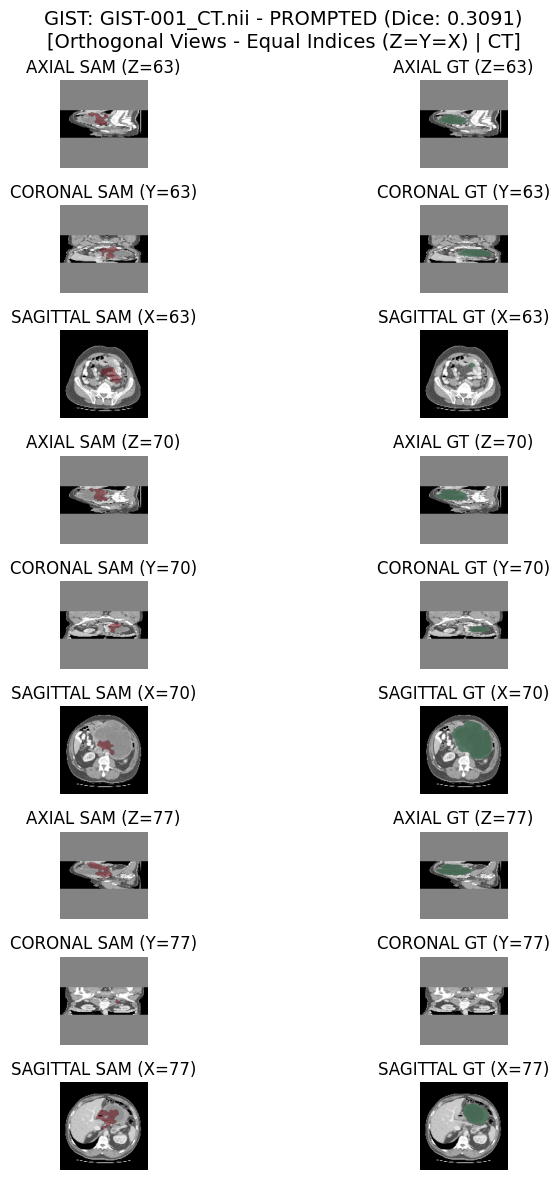

  📸 Plotting UNPROMPTED segmentation [Modality: CT]...

📊 Orthogonal Views: GIST: GIST-001_CT.nii - UNPROMPTED (Dice: 0.0051)
Volume shape: (D=128, H=128, W=128)
Display window: [-227.59, 215.19]
Selected 3D points (Z=Y=X): [(63, 63, 63), (70, 70, 70), (77, 77, 77)]


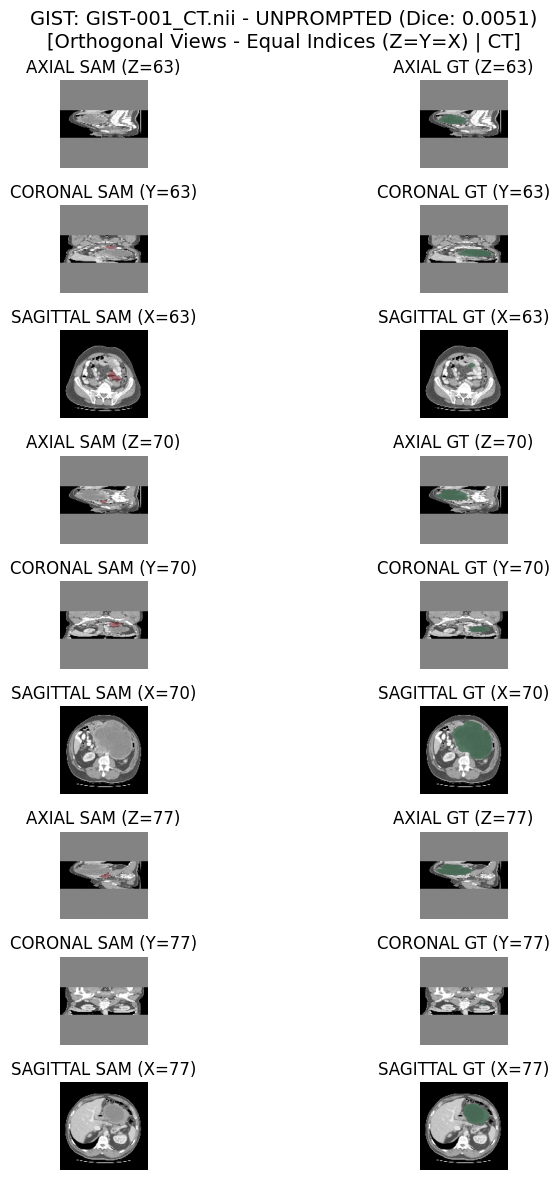


Processing: GIST-002_CT.nii.gz
  Loading image for SAM (WITH normalization)...
    SAM input shape: torch.Size([1, 1, 128, 128, 128])
  Loading image for display (NO normalization)...
    Display shape: (128, 128, 128)
  Loading ground truth mask...
    Mask shape: (128, 128, 128)
    Mask sum: 1704.0 voxels

  🎯 Generating PROMPTED SAM segmentation (uses GT point)...
    Using SINGLE point prompt at: (57, 63, 69)
    Segmentation stats: min=0.000, max=0.949, threshold=0.5, voxels=1386
    Prompted segmentation: 1386 voxels

  🎯 Generating UNPROMPTED SAM segmentation (center point only)...
    Using CENTER point (unprompted): (64, 64, 64)
    Unprompted segmentation stats: min=0.000, max=0.987, threshold=0.5, voxels=1245
    Unprompted segmentation: 1245 voxels

  📊 DICE SCORES:
     Prompted:   0.1877 (uses GT point)
     Unprompted: 0.2211 (center point only)
     Improvement: -0.0334

  📸 Plotting PROMPTED segmentation [Modality: CT]...

📊 Orthogonal Views: GIST: GIST-002_CT.nii - 

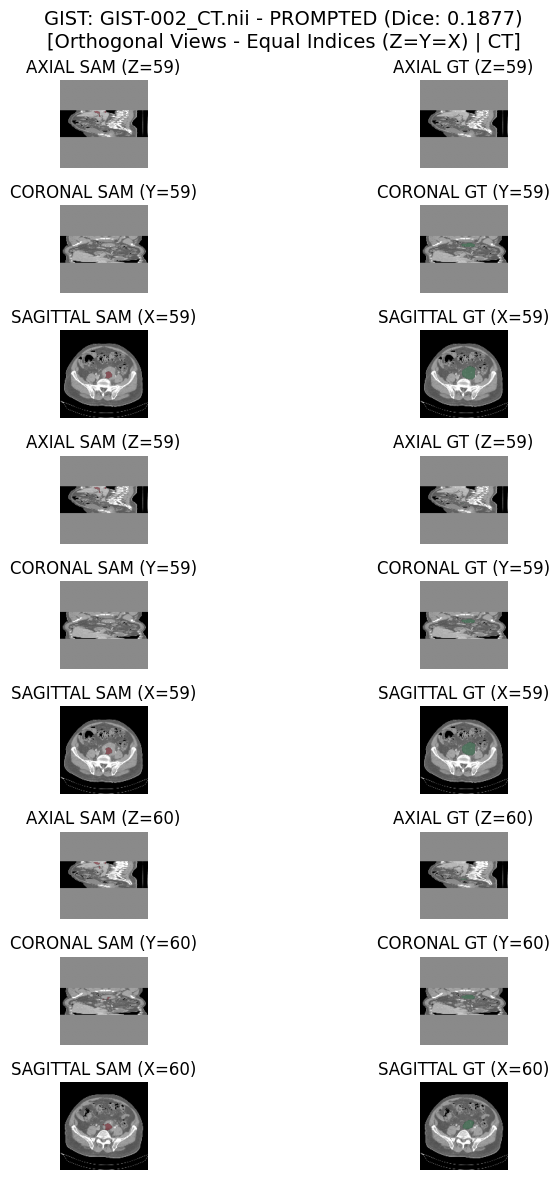

  📸 Plotting UNPROMPTED segmentation [Modality: CT]...

📊 Orthogonal Views: GIST: GIST-002_CT.nii - UNPROMPTED (Dice: 0.2211)
Volume shape: (D=128, H=128, W=128)
Display window: [-329.71, 280.34]
Selected 3D points (Z=Y=X): [(59, 59, 59), (59, 59, 59), (60, 60, 60)]


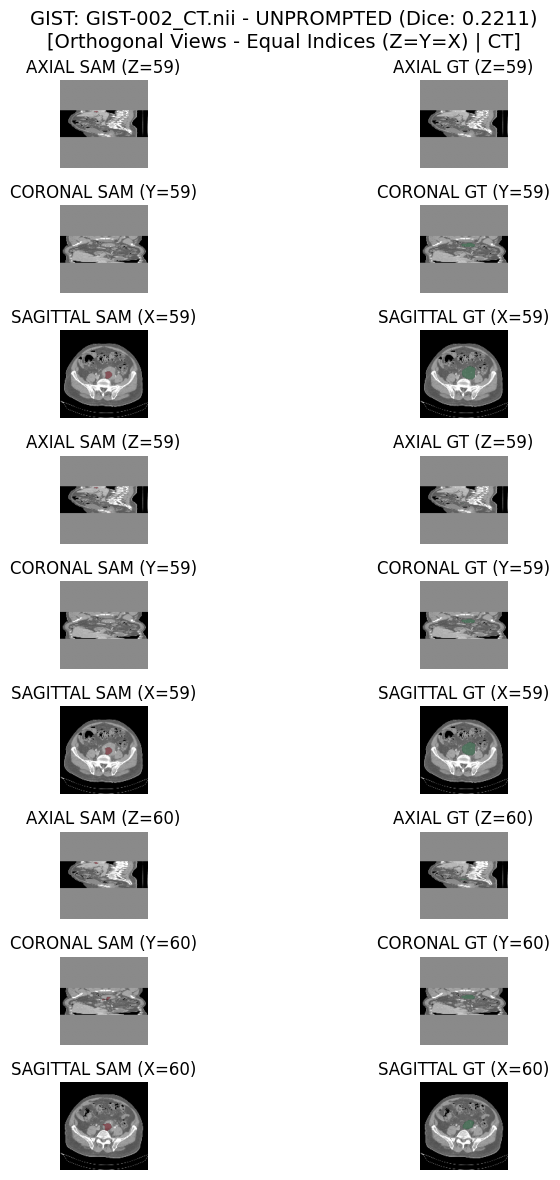


📊 Metrics pass: processing 294 remaining case(s) without plotting

Processing: GIST-003_CT.nii.gz
  Loading image for SAM (WITH normalization)...
    SAM input shape: torch.Size([1, 1, 128, 128, 128])
  Loading image for display (NO normalization)...
    Display shape: (128, 128, 128)
  Loading ground truth mask...
    Mask shape: (128, 128, 128)
    Mask sum: 202.0 voxels

  🎯 Generating PROMPTED SAM segmentation (uses GT point)...
    Using SINGLE point prompt at: (42, 76, 62)
    Segmentation stats: min=0.000, max=0.968, threshold=0.5, voxels=13356
    Prompted segmentation: 13356 voxels

  🎯 Generating UNPROMPTED SAM segmentation (center point only)...
    Using CENTER point (unprompted): (64, 64, 64)
    Unprompted segmentation stats: min=0.000, max=0.992, threshold=0.5, voxels=1536
    Unprompted segmentation: 1536 voxels

  📊 DICE SCORES:
     Prompted:   0.0025 (uses GT point)
     Unprompted: 0.0000 (center point only)
     Improvement: +0.0025
  📉 Skipping plots for metrics-

c:\Users\cahel\.conda\envs\sammed3d\lib\site-packages\torchio\transforms\transform.py:158: RuntimeWarning: Output shape (128, 128, 20) != target shape (np.int64(128), np.int64(128), np.int64(21)). Fixing with CropOrPad
  transformed = self.apply_transform(subject)


    SAM input shape: torch.Size([1, 1, 128, 128, 128])
  Loading image for display (NO normalization)...
    Display shape: (128, 128, 128)
  Loading ground truth mask...
    Mask shape: (128, 128, 128)
    Mask sum: 288.0 voxels

  🎯 Generating PROMPTED SAM segmentation (uses GT point)...
    Using SINGLE point prompt at: (65, 75, 41)
    Segmentation stats: min=0.000, max=0.877, threshold=0.5, voxels=605
    Prompted segmentation: 605 voxels

  🎯 Generating UNPROMPTED SAM segmentation (center point only)...
    Using CENTER point (unprompted): (64, 64, 64)
    Unprompted segmentation stats: min=0.000, max=0.945, threshold=0.5, voxels=927
    Unprompted segmentation: 927 voxels

  📊 DICE SCORES:
     Prompted:   0.0000 (uses GT point)
     Unprompted: 0.0000 (center point only)
     Improvement: +0.0000
  📉 Skipping plots for metrics-only pass

Processing: GIST-005_CT.nii.gz
  Loading image for SAM (WITH normalization)...
    SAM input shape: torch.Size([1, 1, 128, 128, 128])
  Loadin

In [ ]:
results = []
results_dir = project_root / "results" / "sam_visualization"
results_dir.mkdir(parents=True, exist_ok=True)

for dataset_name, dataset_config in config['datasets'].items():
    print("\n" + "="*60)
    print(f"Processing dataset: {dataset_name.upper()}")
    print("="*60)
    
    images, labels = find_dataset_images(dataset_config, sam3d_root, project_root)
    print(f"Found {len(images)} images")
    
    if len(images) == 0:
        print(f"  No images found for {dataset_name}")
        continue
    
    visual_count = min(PLOT_SAMPLES_PER_DATASET, len(images)) if PLOT_SAMPLES_PER_DATASET else 0
    visual_indices = list(range(visual_count))
    metric_indices = [i for i in range(len(images)) if i not in visual_indices]

    passes = []
    if visual_indices:
        passes.append(("visual", visual_indices))
    if metric_indices:
        passes.append(("metrics", metric_indices))

    for pass_type, indices in passes:
        if pass_type == "visual":
            print(f"\n🔍 Visualization pass: showing {len(indices)} sample(s)")
        else:
            print(f"\n📊 Metrics pass: processing {len(indices)} remaining case(s) without plotting")
        
        for idx in indices:
            img_path = images[idx]
            label_path = labels[idx] if idx < len(labels) else None
            
            print(f"\nProcessing: {img_path.name}")
            
            try:
                # Load data
                print(f"  Loading image for SAM (WITH normalization)...")
                image_tensor_sam = load_volume_for_sam(img_path, img_size=img_size)
                print(f"    SAM input shape: {image_tensor_sam.shape}")
                
                print(f"  Loading image for display (NO normalization)...")
                image_vol_display = load_volume_for_display(img_path, img_size=img_size)
                print(f"    Display shape: {image_vol_display.shape}")
                
                print(f"  Loading ground truth mask...")
                gt_mask = load_mask_for_sam(label_path, img_size=img_size) if label_path else None
                if gt_mask is not None:
                    print(f"    Mask shape: {gt_mask.shape}")
                    print(f"    Mask sum: {gt_mask.sum()} voxels")
                
                # Generate PROMPTED segmentation
                print(f"\n  🎯 Generating PROMPTED SAM segmentation (uses GT point)...")
                if gt_mask is not None:
                    seg_prompted = generate_sam_with_bbox_prompt(
                        model, image_tensor_sam, gt_mask, device,
                        use_single_point=USE_SINGLE_POINT_PROMPT
                    )
                else:
                    seg_prompted = generate_sam_with_bbox_prompt(
                        model, image_tensor_sam, np.zeros_like(image_vol_display), device,
                        use_single_point=USE_SINGLE_POINT_PROMPT
                    )
                print(f"    Prompted segmentation: {seg_prompted.sum()} voxels")
                
                # Generate UNPROMPTED segmentation
                print(f"\n  🎯 Generating UNPROMPTED SAM segmentation (center point only)...")
                seg_unprompted = generate_sam_unprompted(
                    model, image_tensor_sam, device,
                    threshold=SEGMENTATION_THRESHOLD
                )
                print(f"    Unprompted segmentation: {seg_unprompted.sum()} voxels")
                
                # Compute Dice scores
                dice_prompted = None
                dice_unprompted = None
                if gt_mask is not None:
                    dice_prompted = compute_dice_score(seg_prompted, gt_mask)
                    dice_unprompted = compute_dice_score(seg_unprompted, gt_mask)
                    improvement = dice_prompted - dice_unprompted
                    
                    print(f"\n  📊 DICE SCORES:")
                    print(f"     Prompted:   {dice_prompted:.4f} (uses GT point)")
                    print(f"     Unprompted: {dice_unprompted:.4f} (center point only)")
                    print(f"     Improvement: {improvement:+.4f}")
                    
                    results.append({
                        "dataset": dataset_name,
                        "image": img_path.name,
                        "dice_prompted": float(dice_prompted),
                        "dice_unprompted": float(dice_unprompted),
                        "dice_improvement": float(improvement)
                    })
                
                # Detect modality from filename
                modality = "MR" if "_MR" in img_path.name or "Lipo" in img_path.name else "CT"
                
                if pass_type == "visual":
                    print(f"\n  📸 Plotting PROMPTED segmentation [Modality: {modality}]...")
                    title_prompted = f"{dataset_name.upper()}: {img_path.stem} - PROMPTED"
                    if dice_prompted is not None:
                        title_prompted += f" (Dice: {dice_prompted:.4f})"
                    
                    fig = plot_orthogonal_views(
                        image_vol_display,
                        seg_prompted,
                        gt_mask,
                        title=title_prompted,
                        n_slices=3,
                        modality=modality
                    )
                    plt.show()
                    
                    print(f"  📸 Plotting UNPROMPTED segmentation [Modality: {modality}]...")
                    title_unprompted = f"{dataset_name.upper()}: {img_path.stem} - UNPROMPTED"
                    if dice_unprompted is not None:
                        title_unprompted += f" (Dice: {dice_unprompted:.4f})"
                    
                    fig = plot_orthogonal_views(
                        image_vol_display,
                        seg_unprompted,
                        gt_mask,
                        title=title_unprompted,
                        n_slices=3,
                        modality=modality
                    )
                    plt.show()
                else:
                    print("  📉 Skipping plots for metrics-only pass")
                
            except Exception as e:
                print(f"  ❌ Error processing {img_path.name}: {e}")
                import traceback
                traceback.print_exc()

if results:
    df_results = pd.DataFrame(results)
    display(df_results)
    
    def _summary_row(label, df):
        n = len(df)
        def _stats(series):
            n_val = len(series)
            mean = series.mean()
            if n_val > 1:
                std = series.std(ddof=1)
                ci = 1.96 * std / np.sqrt(n_val)
            else:
                std = np.nan
                ci = np.nan
            return mean, std, ci
        mean_p, std_p, ci_p = _stats(df['dice_prompted'])
        mean_u, std_u, ci_u = _stats(df['dice_unprompted'])
        mean_i, std_i, ci_i = _stats(df['dice_improvement'])
        return {
            "dataset": label,
            "n_cases": n,
            "mean_prompted": mean_p,
            "std_prompted": std_p,
            "ci95_prompted": ci_p,
            "mean_unprompted": mean_u,
            "std_unprompted": std_u,
            "ci95_unprompted": ci_u,
            "mean_improvement": mean_i,
            "std_improvement": std_i,
            "ci95_improvement": ci_i,
        }

    summary_rows = [_summary_row(ds, grp) for ds, grp in df_results.groupby('dataset')]
    summary_rows.append(_summary_row("ALL", df_results))
    df_summary = pd.DataFrame(summary_rows)
    display(df_summary)
    
    results_csv = results_dir / "dice_scores_per_image.csv"
    summary_csv = results_dir / "dice_scores_summary.csv"
    df_results.to_csv(results_csv, index=False)
    df_summary.to_csv(summary_csv, index=False)
    print(f"\n💾 Saved per-image Dice scores to: {results_csv}")
    print(f"💾 Saved summary statistics to: {summary_csv}")
else:
    print("\n⚠️ No Dice scores computed; skipping summary/CSV export.")

In [ ]:
print("\n" + "="*60)
print("✅ Visualization complete!")
print("="*60)
print("\nFIXES Applied:")
print("1. ✅ CORONAL view with auto-detect modality")
print("   - CT/GIST: dimension 1 (front → back)")
print("   - MR/LIPO: dimension 2 (front → back)")
print("2. ✅ Proper normalization for SAM (fixes segmentation)")
print("3. ✅ Separate display volume (unnormalized for natural look)")
print("4. ✅ Resize-then-pad preprocessing (zero data loss)")


✅ Visualization complete!

FIXES Applied:
1. ✅ CORONAL view with auto-detect modality
   - CT/GIST: dimension 1 (front → back)
   - MR/LIPO: dimension 2 (front → back)
2. ✅ Proper normalization for SAM (fixes segmentation)
3. ✅ Separate display volume (unnormalized for natural look)
4. ✅ Resize-then-pad preprocessing (zero data loss)
